# Step 2 — Train SVR (Support Vector Regressor)

Loads the **6-feature matrix** and continuous steering targets from `01_extract_dataset.ipynb`
and trains an **RBF SVR** to predict the steering offset directly.

Pipeline: `StandardScaler → SVR(kernel=rbf)`

| Input | Shape | Meaning |
|-------|-------|---------|
| `X_features.npy` | (N, 6) | `[off_bot, off_mid, off_top, has_bot, has_mid, has_top]` |
| `y_labels.npy`   | (N,)   | geometric steering label ∈ [-1, +1] |

**Output (saved to `models/` and deployed to `line_following_solution/`):**
- `SVM_Line_Following_SVR.pkl` — Pipeline (StandardScaler + SVR)

## Anti-cheating and anti-bias measures

1. **Temporal block split** — hold out the **last 20% of frames** as a contiguous block.
   Random shuffle would put frame *t* in train and *t+1* in test → trivial leakage from adjacent identical frames.

2. **TimeSeriesSplit CV** — hyperparameter search uses expanding temporal folds so validation
   frames always come *after* training frames, matching real inference conditions.

3. **Scaler fit on train only** — `StandardScaler` fit exclusively on `X_train`, then applied to `X_test`.

4. **Sample weights** — curve frames (`|label| > 0.15`) weighted 3× to fix underfitting on sharp turns
   caused by the majority of frames being straight driving.

5. **Validity flags** — `has_bot/mid/top` features tell the SVR which offsets are real vs filled zeros,
   preventing it from misreading a missing band as "line is centered at car center."


## 1. Imports and paths

In [1]:
from pathlib import Path
import pickle
import shutil

import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

REPO_ROOT  = Path().resolve().parent
DATA_DIR   = REPO_ROOT / "data"
MODELS_DIR = REPO_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)

FEAT_NAMES = ["off_bot", "off_mid", "off_top", "has_bot", "has_mid", "has_top"]
print("Imports OK.")


Imports OK.


## 2. Load dataset

X : (17046, 6)  (N frames × 6 features)
y : (17046,)  (continuous steering labels)

Label range : [-0.397, +0.448]
Mean        : -0.006   Std: 0.117

Label breakdown:
  LEFT     :  5828  (34.2%)
  STRAIGHT :  6798  (39.9%)
  RIGHT    :  4420  (25.9%)

Band availability (has_* flags):
  has_bot : 98.4% of frames
  has_mid : 98.6% of frames
  has_top : 99.3% of frames


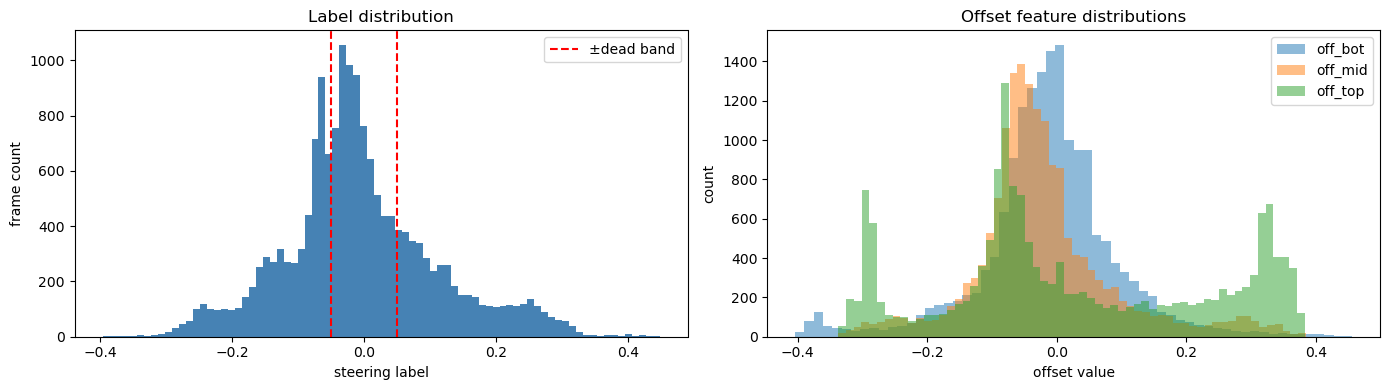

In [2]:
X = np.load(str(DATA_DIR / "X_features.npy"))
y = np.load(str(DATA_DIR / "y_labels.npy"))

assert X.shape[1] == 6, f"Expected 6 features, got {X.shape[1]} — re-run notebook 01"
print(f"X : {X.shape}  (N frames × 6 features)")
print(f"y : {y.shape}  (continuous steering labels)")
print(f"\nLabel range : [{y.min():+.3f}, {y.max():+.3f}]")
print(f"Mean        : {y.mean():+.3f}   Std: {y.std():.3f}")

DEAD_BAND = 0.05
n_left     = (y < -DEAD_BAND).sum()
n_straight = ((y >= -DEAD_BAND) & (y <= DEAD_BAND)).sum()
n_right    = (y > DEAD_BAND).sum()
print(f"\nLabel breakdown:")
print(f"  LEFT     : {n_left:5d}  ({100*n_left/len(y):.1f}%)")
print(f"  STRAIGHT : {n_straight:5d}  ({100*n_straight/len(y):.1f}%)")
print(f"  RIGHT    : {n_right:5d}  ({100*n_right/len(y):.1f}%)")

# Band availability stats
print(f"\nBand availability (has_* flags):")
print(f"  has_bot : {X[:, 3].mean()*100:.1f}% of frames")
print(f"  has_mid : {X[:, 4].mean()*100:.1f}% of frames")
print(f"  has_top : {X[:, 5].mean()*100:.1f}% of frames")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(y, bins=80, color="steelblue", edgecolor="none")
axes[0].axvline(-DEAD_BAND, color="red", linestyle="--", linewidth=1.5, label="±dead band")
axes[0].axvline( DEAD_BAND, color="red", linestyle="--", linewidth=1.5)
axes[0].set_xlabel("steering label")
axes[0].set_ylabel("frame count")
axes[0].set_title("Label distribution")
axes[0].legend()

for i, name in enumerate(FEAT_NAMES[:3]):   # only plot offset features
    axes[1].hist(X[:, i], bins=60, alpha=0.5, label=name, edgecolor="none")
axes[1].set_xlabel("offset value")
axes[1].set_ylabel("count")
axes[1].set_title("Offset feature distributions")
axes[1].legend()
plt.tight_layout()
plt.show()


## 3. Temporal block train / test split

Frames come from a video — neighbouring frames are nearly identical. A random shuffle
would put frame *t* in train and frame *t+1* in test, making the task trivially easy
(the model just memorises local patches rather than learning to steer).

**Fix:** hold out the **last 20 % of frames** as a contiguous block. The boundary between
train and test is a single point in time, so no training frame is adjacent to any test frame.

```
Frames:  0 ──────────────────────── 80% ──── 100%
                  TRAIN                   TEST (held out)
```


In [3]:
TEST_FRAC = 0.20   # hold out last 20% as contiguous block

split_idx = int(len(X) * (1 - TEST_FRAC))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Total frames : {len(X)}")
print(f"Train        : {len(X_train)} frames  (frames 0 – {split_idx-1})")
print(f"Test         : {len(X_test)}  frames  (frames {split_idx} – {len(X)-1})  ← held out, never seen during tuning")


Total frames : 17046
Train        : 13636 frames  (frames 0 – 13635)
Test         : 3410  frames  (frames 13636 – 17045)  ← held out, never seen during tuning


## 4. Baseline SVR — quick sanity check

Fit a default SVR on training data only, evaluate on the held-out test block.
This tells us whether the features carry signal at all before we spend time tuning.


Sample weights: straight=1.0  curves=3.0  (|label| > 0.15)
  Curve frames in train : 2545 / 13636

Baseline MAE : 0.0198   (trained on 2728 frames, tested on 3410)
Baseline R²  : 0.9502


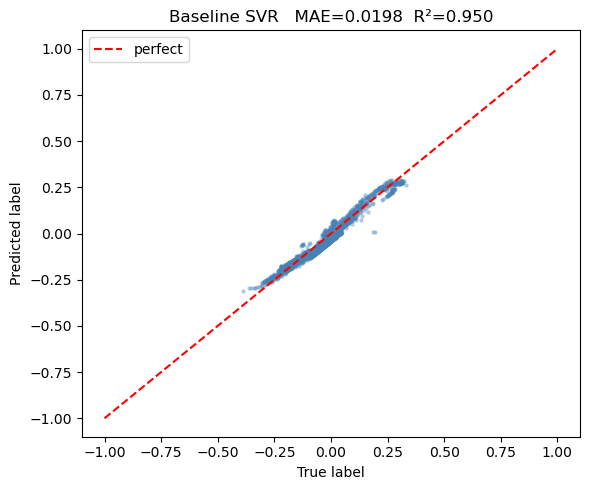

In [4]:
CURVE_THRESHOLD = 0.15
sample_weights = np.where(np.abs(y_train) > CURVE_THRESHOLD, 3.0, 1.0)
print(f"Sample weights: straight=1.0  curves=3.0  (|label| > {CURVE_THRESHOLD})")
print(f"  Curve frames in train : {(np.abs(y_train) > CURVE_THRESHOLD).sum()} / {len(y_train)}")

BASELINE_SUBSAMPLE = 5
X_bl = np.ascontiguousarray(X_train[::BASELINE_SUBSAMPLE])
y_bl = np.ascontiguousarray(y_train[::BASELINE_SUBSAMPLE])
w_bl = np.ascontiguousarray(sample_weights[::BASELINE_SUBSAMPLE])

baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("svr",    SVR(kernel="rbf", C=1.0, gamma="scale", epsilon=0.05)),
])
baseline.fit(X_bl, y_bl, svr__sample_weight=w_bl)
y_pred_base = baseline.predict(X_test)

mae_base = mean_absolute_error(y_test, y_pred_base)
r2_base  = r2_score(y_test, y_pred_base)
print(f"\nBaseline MAE : {mae_base:.4f}   (trained on {len(X_bl)} frames, tested on {len(X_test)})")
print(f"Baseline R²  : {r2_base:.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_test, y_pred_base, alpha=0.3, s=5, color="steelblue")
ax.plot([-1, 1], [-1, 1], "r--", linewidth=1.5, label="perfect")
ax.set_xlabel("True label")
ax.set_ylabel("Predicted label")
ax.set_title(f"Baseline SVR   MAE={mae_base:.4f}  R²={r2_base:.3f}")
ax.legend()
plt.tight_layout()
plt.show()


## 5. TimeSeriesSplit cross-validation — hyperparameter search

`TimeSeriesSplit` with 5 folds creates expanding training windows:

```
Fold 1:  train=[0..20%]   val=[20..40%]
Fold 2:  train=[0..40%]   val=[40..60%]
Fold 3:  train=[0..60%]   val=[60..80%]   ← approximate (splits train block only)
...
```

Each validation split only contains frames that come *after* all training frames in that fold.
This is how the model will actually be used — it trains on past frames and infers on future ones.

The **held-out test block (last 20 %) is never touched** during this search.


In [5]:
TUNE_SUBSAMPLE = 5
X_tune = np.ascontiguousarray(X_train[::TUNE_SUBSAMPLE])
y_tune = np.ascontiguousarray(y_train[::TUNE_SUBSAMPLE])
w_tune = np.ascontiguousarray(sample_weights[::TUNE_SUBSAMPLE])
print(f"Grid-search subset : {len(X_tune)} frames (every {TUNE_SUBSAMPLE}th frame, order preserved)")

# Wider grid to find better regularization after label formula update.
# Lower C = stronger regularization = less overfitting to training labels.
# Higher epsilon = wider insensitive tube = ignores small label noise from formula.
# gamma='scale' vs 0.1 — 0.1 gives softer RBF kernel, less prone to memorising training points.
param_grid = {
    "svr__C":       [1, 5, 10, 50],       # added C=1 and C=5 for stronger regularization
    "svr__gamma":   ["scale", 0.1, 0.5],  # added 0.1 for softer kernel
    "svr__epsilon": [0.01, 0.05, 0.10],   # added 0.10 to tolerate label formula noise
}

tscv = TimeSeriesSplit(n_splits=5)

grid = GridSearchCV(
    Pipeline([
        ("scaler", StandardScaler()),
        ("svr",    SVR(kernel="rbf")),
    ]),
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    n_jobs=-1,
    verbose=1,
)
grid.fit(X_tune, y_tune, svr__sample_weight=w_tune)

print(f"\nBest parameters : {grid.best_params_}")
print(f"Best CV MAE     : {-grid.best_score_:.4f}  (on tune subset, 5 temporal folds)")

# Show top 5 candidates so we can see the trade-off landscape
results = grid.cv_results_
top5_idx = np.argsort(results["mean_test_score"])[-5:][::-1]
print("\nTop 5 parameter combinations:")
for i in top5_idx:
    params = results["params"][i]
    mae    = -results["mean_test_score"][i]
    std    = results["std_test_score"][i]
    print(f"  MAE={mae:.4f} ±{std:.4f}  C={params['svr__C']:3}  gamma={str(params['svr__gamma']):6}  epsilon={params['svr__epsilon']}")

Grid-search subset : 2728 frames (every 5th frame, order preserved)
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best parameters : {'svr__C': 5, 'svr__epsilon': 0.01, 'svr__gamma': 0.1}
Best CV MAE     : 0.0136  (on tune subset, 5 temporal folds)

Top 5 parameter combinations:
  MAE=0.0136 ±0.0095  C=  5  gamma=0.1     epsilon=0.01
  MAE=0.0138 ±0.0096  C=  1  gamma=0.1     epsilon=0.01
  MAE=0.0138 ±0.0093  C= 10  gamma=0.1     epsilon=0.01
  MAE=0.0147 ±0.0092  C= 50  gamma=0.1     epsilon=0.01
  MAE=0.0157 ±0.0133  C=  1  gamma=scale   epsilon=0.01


## 6. Evaluate tuned model on held-out test block

First time the test set is used — scores here are unbiased estimates of real-world performance.


Tuned MAE  : 0.0075   (baseline was 0.0198)
Tuned R²   : 0.9909   (baseline was 0.9502)

Improvement: 62.4% MAE reduction


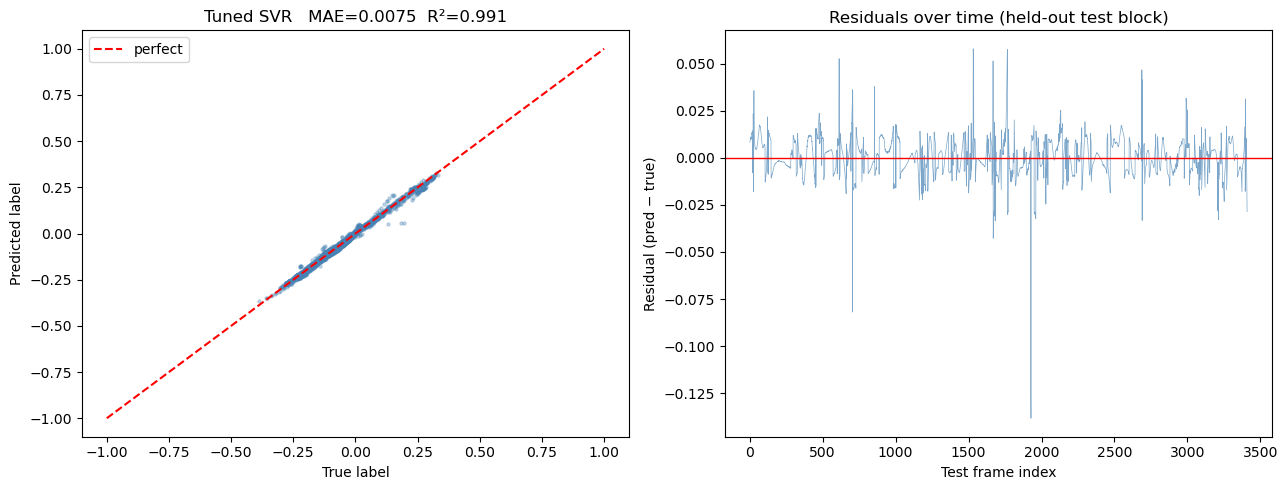

In [6]:
best_model  = grid.best_estimator_
y_pred_best = best_model.predict(X_test)

mae_tuned = mean_absolute_error(y_test, y_pred_best)
r2_tuned  = r2_score(y_test, y_pred_best)
print(f"Tuned MAE  : {mae_tuned:.4f}   (baseline was {mae_base:.4f})")
print(f"Tuned R²   : {r2_tuned:.4f}   (baseline was {r2_base:.4f})")
print(f"\nImprovement: {(mae_base - mae_tuned) / mae_base * 100:.1f}% MAE reduction")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter: predicted vs true
axes[0].scatter(y_test, y_pred_best, alpha=0.3, s=5, color="steelblue")
axes[0].plot([-1, 1], [-1, 1], "r--", linewidth=1.5, label="perfect")
axes[0].set_xlabel("True label")
axes[0].set_ylabel("Predicted label")
axes[0].set_title(f"Tuned SVR   MAE={mae_tuned:.4f}  R²={r2_tuned:.3f}")
axes[0].legend()

# Residuals over time (test block only — temporal order preserved)
residuals = y_pred_best - y_test
axes[1].plot(residuals, linewidth=0.5, alpha=0.7, color="steelblue")
axes[1].axhline(0, color="red", linewidth=1.0)
axes[1].set_xlabel("Test frame index")
axes[1].set_ylabel("Residual (pred − true)")
axes[1].set_title("Residuals over time (held-out test block)")

plt.tight_layout()
plt.show()


## 7. Feature importance — permutation test

Shuffle each feature independently on the test set and measure how much MAE rises.
A feature that doesn't matter will show ~0 increase; a critical feature will cause a large increase.


  off_bot     : MAE increase = +0.0445
  off_mid     : MAE increase = +0.0252
  off_top     : MAE increase = +0.0396
  has_bot     : MAE increase = +0.0009
  has_mid     : MAE increase = +0.0007
  has_top     : MAE increase = +0.0001


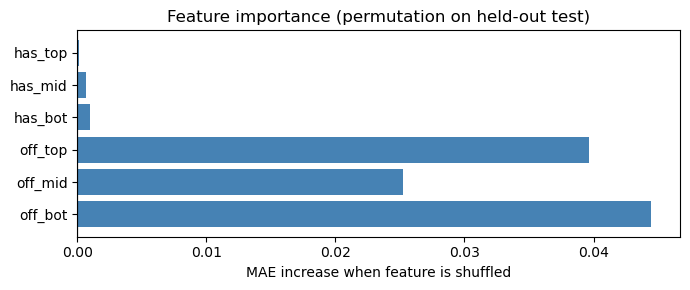

In [7]:
rng      = np.random.default_rng(RANDOM_STATE)
base_mae = mean_absolute_error(y_test, best_model.predict(X_test))
drops    = []

for i, name in enumerate(FEAT_NAMES):
    X_perm       = X_test.copy()
    X_perm[:, i] = rng.permutation(X_perm[:, i])
    perm_mae     = mean_absolute_error(y_test, best_model.predict(X_perm))
    increase     = perm_mae - base_mae
    drops.append(increase)
    print(f"  {name:12s}: MAE increase = {increase:+.4f}")

plt.figure(figsize=(7, 3))
plt.barh(FEAT_NAMES, drops, color="steelblue")
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("MAE increase when feature is shuffled")
plt.title("Feature importance (permutation on held-out test)")
plt.tight_layout()
plt.show()


## 8. Retrain on full dataset and save

After confirming the tuned hyperparameters on the held-out test, retrain on **all** frames
(train + test combined) so the deployed model benefits from every labeled example.

The final `.pkl` is a `Pipeline(StandardScaler + SVR)` — call `model.predict(X)` directly,
no manual scaling needed.


In [8]:
all_weights = np.where(np.abs(y) > CURVE_THRESHOLD, 3.0, 1.0)

final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svr",    SVR(kernel="rbf", **{k.replace("svr__", ""): v for k, v in grid.best_params_.items()})),
])
final_model.fit(X, y, svr__sample_weight=all_weights)

MODEL_PATH  = MODELS_DIR / "SVM_Line_Following_SVR.pkl"
DEPLOY_PATH = REPO_ROOT / "line_following_solution" / "SVM_Line_Following_SVR.pkl"

with open(str(MODEL_PATH), "wb") as f:
    pickle.dump(final_model, f)
shutil.copy(str(MODEL_PATH), str(DEPLOY_PATH))

print(f"Saved   : {MODEL_PATH}")
print(f"Deployed: {DEPLOY_PATH}")

with open(str(MODEL_PATH), "rb") as f:
    loaded = pickle.load(f)

sample_preds = loaded.predict(X[-5:])
print("\nFinal model — last 5 frames:")
for true, pred in zip(y[-5:], sample_preds):
    direction = "L" if pred < -0.05 else "R" if pred > 0.05 else "S"
    print(f"  true={true:+.3f}  pred={pred:+.3f}  ({direction})")

print(f"\nBest hyperparams      : {grid.best_params_}")
print(f"CV MAE (temporal)     : {-grid.best_score_:.4f}")
print(f"Test MAE              : {mae_tuned:.4f}")
print(f"Test R²               : {r2_tuned:.4f}")
print(f"Features              : {FEAT_NAMES}")
print(f"Curve sample weight   : 3.0× for |label| > {CURVE_THRESHOLD}")
print("\nDone. my_line_follower.py loads SVM_Line_Following_SVR.pkl automatically.")


Saved   : D:\HSHL_resources_v2\6th_Semester\New folder\Autonomous_Systems_A_Lab_Group_4\models\SVM_Line_Following_SVR.pkl
Deployed: D:\HSHL_resources_v2\6th_Semester\New folder\Autonomous_Systems_A_Lab_Group_4\line_following_solution\SVM_Line_Following_SVR.pkl

Final model — last 5 frames:
  true=+0.067  pred=+0.065  (R)
  true=+0.091  pred=+0.085  (R)
  true=+0.110  pred=+0.103  (R)
  true=+0.138  pred=+0.138  (R)
  true=+0.162  pred=+0.172  (R)

Best hyperparams      : {'svr__C': 5, 'svr__epsilon': 0.01, 'svr__gamma': 0.1}
CV MAE (temporal)     : 0.0136
Test MAE              : 0.0075
Test R²               : 0.9909
Features              : ['off_bot', 'off_mid', 'off_top', 'has_bot', 'has_mid', 'has_top']
Curve sample weight   : 3.0× for |label| > 0.15

Done. my_line_follower.py loads SVM_Line_Following_SVR.pkl automatically.
